# Adding Objects

In [1]:
import bpy
bpy.app.version_string # current blender version

'5.3.0 Beta'

In [2]:
import sys
from pathlib import Path

# The kernel runs inside Blender (not in the notebook folder), so add the docs helpers to sys.path
sys.path.append(str(Path.home() / "projects/bpy-gallery/docs/utils"))
from gallery_utils import ASSETS, fresh_scene, render_result

# Set render resolution
bpy.context.scene.render.resolution_x = 500
bpy.context.scene.render.resolution_y = 200

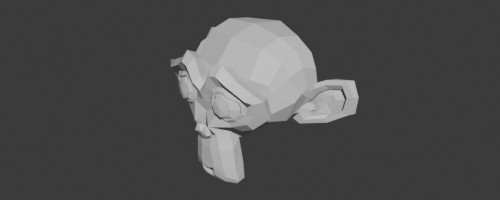

In [3]:
fresh_scene()
bpy.ops.mesh.primitive_monkey_add(size=2.5, location=(0, 0, 0))
render_result()

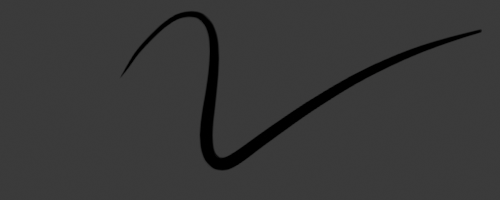

In [4]:
fresh_scene()
#bpy.ops.object.gpencil_add(location=(0, 0, 0), type='STROKE') # Blender 4.2
bpy.ops.object.grease_pencil_add(location=(0, 0, 0), type="STROKE") # Blender 4.3.1
gpencil_object = bpy.context.active_object
gpencil_object.scale = (3, 3, 3)
render_result()

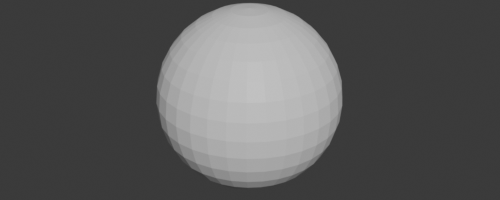

In [5]:
fresh_scene()
bpy.ops.mesh.primitive_uv_sphere_add(radius=1.5, location=(0, 0, 0)) 
render_result()

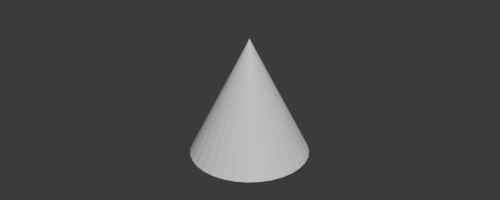

In [6]:
fresh_scene()
bpy.ops.mesh.primitive_cone_add(radius1=1, depth=2, location=(0, 0, 0))  
render_result()

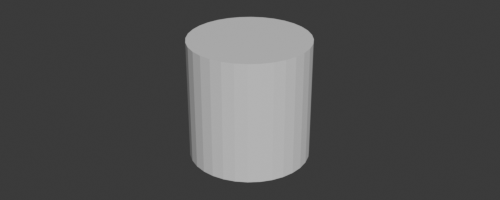

In [7]:
fresh_scene()
bpy.ops.mesh.primitive_cylinder_add(radius=1, depth=2, location=(0, 0, 0)) 
render_result()

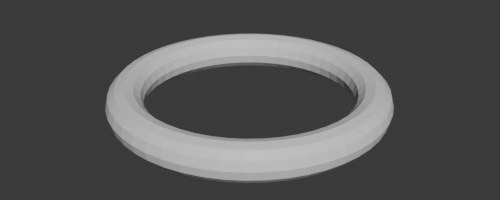

In [8]:
fresh_scene()
bpy.ops.mesh.primitive_torus_add(major_radius=2, minor_radius=0.3, location=(0,0, 0))
render_result()

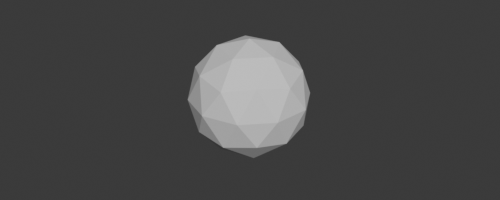

In [9]:
fresh_scene()
bpy.ops.mesh.primitive_ico_sphere_add(radius=1, location=(0, 0, 0)) 
render_result()

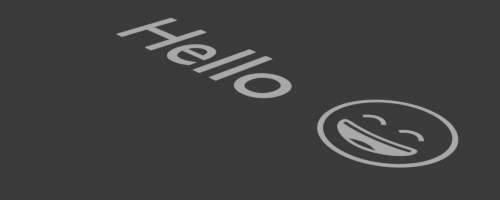

In [10]:
fresh_scene()
bpy.ops.object.text_add(location=(-4, 0, 0))
text = bpy.context.active_object
text.data.body = "Hello 😄"
text.scale = (2, 2, 2)
render_result()

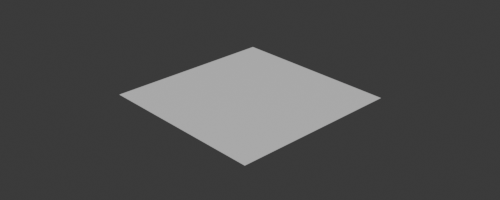

In [11]:
fresh_scene()
bpy.ops.mesh.primitive_plane_add(size=3, location=(0, 0, 0))  
render_result()

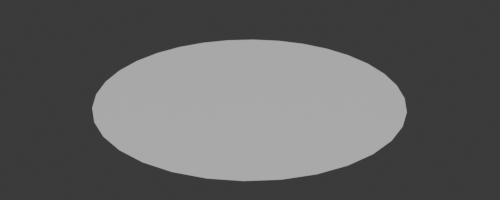

In [12]:
fresh_scene()
bpy.ops.mesh.primitive_circle_add(radius=2.5, location=(0, 0, 0), fill_type='NGON')
render_result()

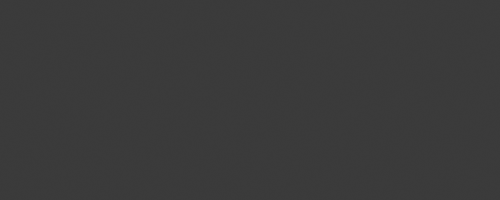

In [13]:
fresh_scene()
bpy.ops.object.empty_add(type='PLAIN_AXES', location=(4, 0, 0)) # (This is not shown in the image, but it is there)
render_result()

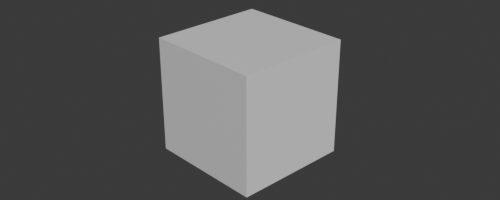

In [14]:
fresh_scene()
bpy.ops.mesh.primitive_cube_add(size=2, location=(0, 0, 0)) 
render_result()

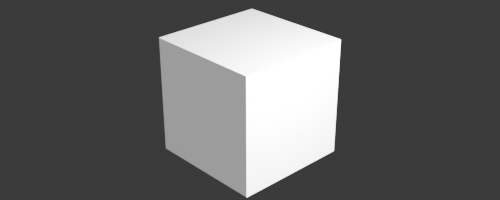

In [15]:
fresh_scene()
bpy.ops.mesh.primitive_cube_add(size=2, location=(0, 0, 0)) 
light = bpy.data.objects.new("Light", bpy.data.lights.new("Light", 'POINT'))
light.location = (3, 0, 2)
light.data.energy = 8000
bpy.context.collection.objects.link(light)
render_result()

# Applying Modifiers

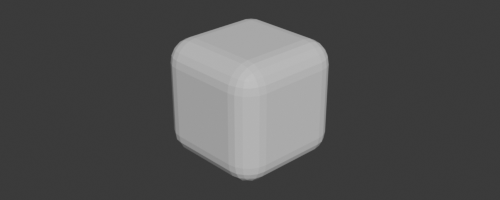

In [16]:
fresh_scene()
bpy.ops.mesh.primitive_cube_add(size=2, location=(0, 0, 0)) 
cube = bpy.context.active_object
bevel_modifier = cube.modifiers.new(name="Bevel", type='BEVEL')
bevel_modifier.width = 0.4  # Adjust the bevel width
bevel_modifier.segments = 5  # Number of segments for a smoother bevel

# Optionally apply the modifier if needed (not necessary for visualization)
# bpy.ops.object.modifier_apply(modifier="Bevel")

render_result()

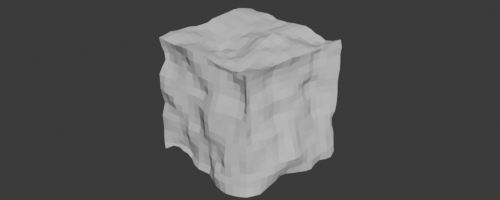

In [17]:
fresh_scene()
bpy.ops.mesh.primitive_cube_add(size=2, location=(0, 0, 0))
cube = bpy.context.active_object

# Create the subdivision surface modifier and change it to 'SIMPLE'
subsurf_modifier = cube.modifiers.new(name="Subdivision", type='SUBSURF')
subsurf_modifier.subdivision_type = 'SIMPLE'  # Change to 'SIMPLE' instead of 'CATMULL_CLARK'
subsurf_modifier.levels = 4  # Viewport subdivision level
subsurf_modifier.render_levels = 4  # Render subdivision level

displace_modifier = cube.modifiers.new(name="Displace", type='DISPLACE')
displace_modifier.strength = 0.5  # Adjust the displacement strength

texture = bpy.data.textures.new("DisplaceTexture", type='CLOUDS')
texture.noise_scale = 1  # Reduce the noise scale to make it more detailed
displace_modifier.texture = texture  # Assign the texture to the modifier

render_result()

# Settings

In [18]:
# current blender version
bpy.app.version_string

'5.3.0 Beta'

In [19]:
# current blender version
bpy.context.scene.render.engine

'BLENDER_EEVEE'

In [20]:
bpy.context.scene.render.resolution_x, bpy.context.scene.render.resolution_y

(500, 200)

In [21]:
bpy.context.scene.name

'Scene'

In [22]:
bpy.context.active_object.name

'Cube'

In [23]:
bpy.context.active_object.location

Vector((0.0, 0.0, 0.0))

In [24]:
bpy.context.collection.objects.keys()

['Camera', 'Sun', 'Cube']

In [25]:
bpy.context.collection.objects.values()

[bpy.data.objects['Camera'], bpy.data.objects['Sun'], bpy.data.objects['Cube']]

# Using colors

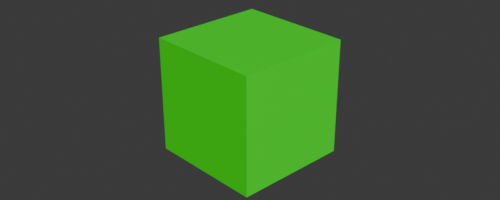

In [26]:
fresh_scene()

# Add a cube
bpy.ops.mesh.primitive_cube_add(size=2, location=(0, 0, 0))
cube = bpy.context.active_object

# Create a green material
mat = bpy.data.materials.new(name="GreenMaterial")
mat.diffuse_color = (0, 1, 0, 1)  # viewport color only (Solid mode)
mat.node_tree.nodes["Principled BSDF"].inputs["Base Color"].default_value = (0, 1, 0, 1)  # render color

# Apply material to the cube
cube.data.materials.clear()  # Clear any existing materials
cube.data.materials.append(mat)

render_result()

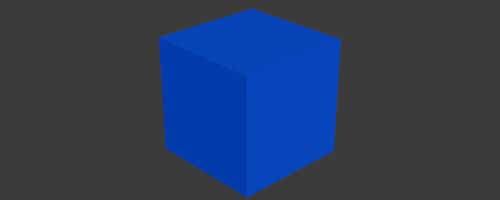

In [27]:
fresh_scene()

# colors with nodes

bpy.ops.mesh.primitive_cube_add(size=2, location=(0, 0, 0))
cube = bpy.context.active_object

# Create and assign a blue material to the cube
mat = bpy.data.materials.new(name="BlueMaterial")
# mat.use_nodes = True  # outdated: materials always use nodes since Blender 5.0
bsdf = mat.node_tree.nodes.get('Principled BSDF')
bsdf.inputs['Base Color'].default_value = (0, 0, 1, 1)  # Blue color (R, G, B, A)

# Apply material to the cube
cube.data.materials.clear()  # Clear any existing materials
cube.data.materials.append(mat)
render_result()

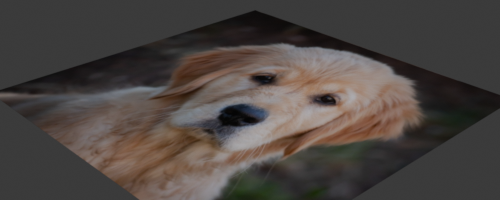

In [28]:
fresh_scene()

bpy.ops.mesh.primitive_plane_add(size=6, location=(0, 0, 0))
# plane = bpy.context.object # only blender 4.1
plane = bpy.context.active_object #blender 4.3

material = bpy.data.materials.new(name="ImageMaterial")
# material.use_nodes = True  # outdated: materials always use nodes since Blender 5.0
bsdf = material.node_tree.nodes["Principled BSDF"]

tex_image = material.node_tree.nodes.new('ShaderNodeTexImage')

tex_image.image = bpy.data.images.load(str(ASSETS / "cute_dog.jpg"))

material.node_tree.links.new(bsdf.inputs['Base Color'], tex_image.outputs['Color'])
plane.data.materials.append(material)

render_result()

# Setting Up Shaders

Node trees can be written as code with [nodebpy](https://github.com/BradyAJohnston/nodebpy). Install it once into Blender's Python with `pip`:

In [29]:
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "nodebpy"])


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: /Applications/Blender.app/Contents/Resources/5.3/python/bin/python3.13 -m pip install --upgrade pip


0

In [30]:
import importlib.metadata

importlib.metadata.version("nodebpy")

'520.35.1'

This builds the following shader tree:  
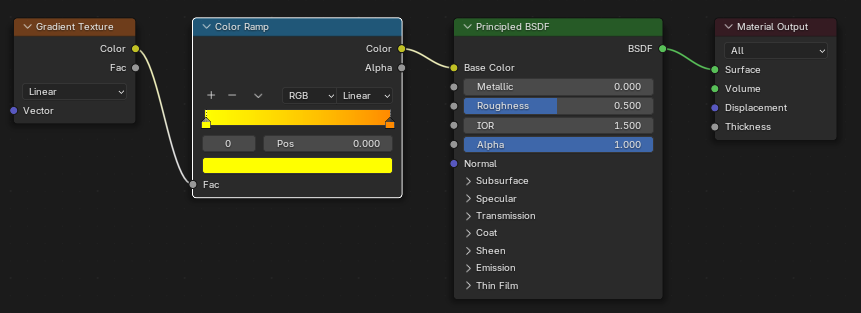

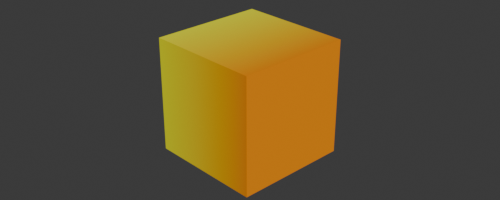

In [31]:
fresh_scene()

from nodebpy import shader as s

bpy.ops.mesh.primitive_cube_add(size=2, location=(0, 0, 0))
cube = bpy.context.active_object

with s.material("YellowToOrangeGradient") as tree:
    _ = (
        s.GradientTexture(gradient_type="LINEAR")
        >> s.ColorRamp(items=[(0.0, (1, 1, 0, 1)), (1.0, (1, 0.3, 0, 1))])  # yellow -> orange
        >> s.PrincipledBSDF()
        >> s.MaterialOutput()
    )

cube.data.materials.clear()
cube.data.materials.append(tree.material)

render_result()

# Setting up Geometry Nodes
The same works for geometry node trees:

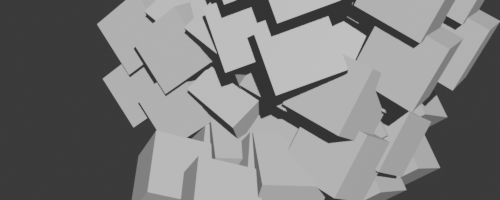

In [32]:
fresh_scene()

from nodebpy import geometry as g

bpy.ops.mesh.primitive_cube_add(size=2, location=(0, 0, 0))

with g.tree("AnotherTree", collapse=True, arrange="sugiyama") as tree:
    rotation = (
        g.RandomValue.vector(min=-1, seed=2)
        >> g.AlignRotationToVector()
        >> g.RotateRotation(rotate_by=g.AxisAngleToRotation(angle=0.3))
    )

    _ = (
        tree.inputs.integer("Count", 10)
        >> g.Points(position=g.RandomValue.vector(min=-1))
        >> g.InstanceOnPoints(instance=g.Cube(), rotation=rotation)
        >> g.SetPosition(
            position=g.Position() * 2.0 + (0, 0.2, 0.3),
            offset=(0, 0, 0.1),
        )
        >> g.RealizeInstances()
        >> g.InstanceOnPoints(g.Cube(), instance=...)
        >> tree.outputs.geometry("Instances")
    )

# Apply to active object
obj = bpy.context.active_object
modifier = obj.modifiers.new(name="AnotherTree", type="NODES")
modifier.node_group = bpy.data.node_groups["AnotherTree"]

render_result()

# Save File
You can any time also save your Blender file like this:

In [33]:
path = str(Path.home() / 'Downloads/temp_scene.blend')
bpy.ops.wm.save_as_mainfile(filepath=path) 

Info: Saved as "temp_scene.blend"


{'FINISHED'}

# Load file

In [34]:
fresh_scene()
#bpy.ops.wm.open_mainfile(filepath="donut.blend") # this will loose kernel connection

filepath = str(ASSETS / "donut.blend")

# Import all objects from the .blend file
with bpy.data.libraries.load(filepath, link=False) as (data_from, data_to):
    data_to.objects = data_from.objects

# Link imported objects to the current scene
for obj in data_to.objects:
    if obj is not None:
        bpy.context.collection.objects.link(obj)

# Render through the camera that came with donut.blend
bpy.context.scene.camera = next(obj for obj in data_to.objects if obj.type == 'CAMERA')

# Choose render engine

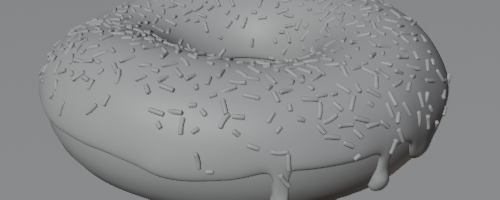

In [35]:
bpy.context.scene.render.engine = "BLENDER_WORKBENCH" 

bpy.context.scene.render.resolution_x = 500
bpy.context.scene.render.resolution_y = 200

render_result()

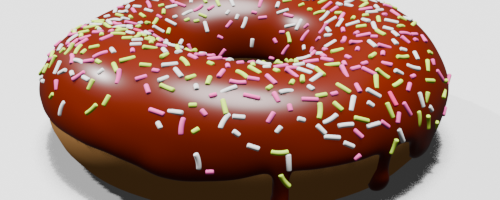

In [36]:
bpy.context.scene.render.engine = "BLENDER_EEVEE"
render_result()

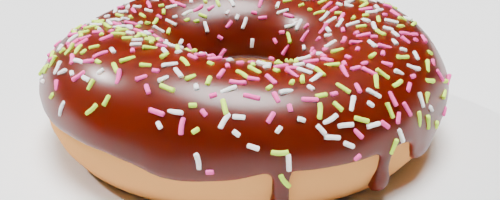

In [37]:
bpy.context.scene.render.engine = "CYCLES"
bpy.context.scene.cycles.samples = 10
render_result()

# Manipulate geometry nodes

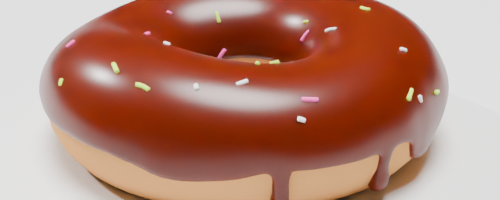

In [38]:
# old 
# bpy.data.objects['ICINGLong'].modifiers["GeometryNodes"]["Socket_3"] = 0.1

#new:
bpy.data.objects["ICINGLong"].modifiers["GeometryNodes"].properties.inputs.Socket_3.value = 0.1
render_result()

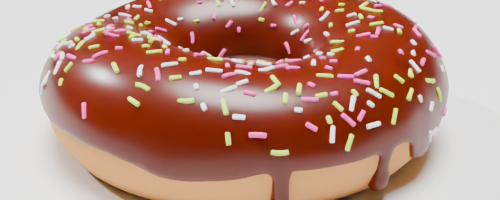

In [39]:
bpy.data.objects["ICINGLong"].modifiers["GeometryNodes"].properties.inputs.Socket_3.value = 2
render_result()

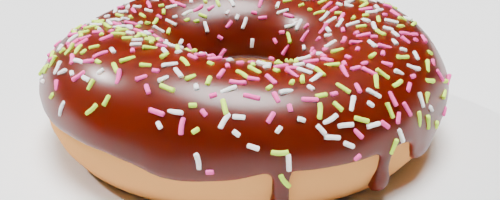

In [40]:
bpy.data.objects["ICINGLong"].modifiers["GeometryNodes"].properties.inputs.Socket_3.value = 10
render_result()